In [1]:
from pathlib import Path


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: c:\Users\adanm\Code\tesis


In [2]:
import sys

import pandas as pd
import matplotlib.pyplot as plt


if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from experimento_aa import (
    prepare_aa_data,
    train_aa_and_reconstruct,
    calculate_aa_metrics,
)

Using NumPy backend


In [3]:
DATASETS = (
    "interpolacion_50",
    "interpolacion_100",
    "medianas_fase_50",
    "medianas_fase_100",
)

NORMALIZACION_SELECCIONADA = "minmax"
K_SELECCIONADO = 5
INICIALIZACION_AA = "pca_convex_hull_furthest_sum"

N_ESTRELLAS_SUBMUESTRA = 5000
SEMILLA_MUESTREO = 42
SEMILLA_MODELO = 0

In [4]:
from sklearn.model_selection import train_test_split


_, _, metadata_train_referencia, _ = prepare_aa_data(
    dataset="interpolacion_50",
    normalizacion=NORMALIZACION_SELECCIONADA,
)

subtipos_por_estrella = (
    metadata_train_referencia[
        ["star_id_base", "subtipo_rrlyrae"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

estrellas_submuestra, _ = train_test_split(
    subtipos_por_estrella,
    train_size=N_ESTRELLAS_SUBMUESTRA,
    random_state=SEMILLA_MUESTREO,
    stratify=subtipos_por_estrella["subtipo_rrlyrae"],
)

ids_submuestra = set(
    estrellas_submuestra["star_id_base"]
)

print(
    "Estrellas seleccionadas: "
    f"{len(ids_submuestra):,}"
)

print("\nEstrellas por subtipo:")
print(
    estrellas_submuestra[
        "subtipo_rrlyrae"
    ].value_counts()
)

Estrellas seleccionadas: 5,000

Estrellas por subtipo:
subtipo_rrlyrae
RRab    3535
RRc     1299
RRd      166
Name: count, dtype: int64


In [5]:
resultados_representacion = []
arquetipos_por_representacion = {}


for dataset in DATASETS:
    print(
        "\n"
        + "=" * 60
        + f"\nDataset: {dataset}"
        + "\n"
        + "=" * 60
    )

    X_train_dataset, X_val_dataset, metadata_train_dataset, metadata_val_dataset = (
        prepare_aa_data(
            dataset=dataset,
            normalizacion=NORMALIZACION_SELECCIONADA,
        )
    )

    mascara_submuestra = (
        metadata_train_dataset["star_id_base"]
        .isin(ids_submuestra)
        .to_numpy()
    )

    X_train_submuestra = X_train_dataset[
        mascara_submuestra
    ]

    metadata_train_submuestra = (
        metadata_train_dataset.loc[mascara_submuestra]
        .reset_index(drop=True)
    )

    if (
        metadata_train_submuestra["star_id_base"].nunique()
        != N_ESTRELLAS_SUBMUESTRA
    ):
        raise ValueError(
            f"{dataset} no contiene las 5.000 estrellas esperadas."
        )

    resultado_modelo = train_aa_and_reconstruct(
        X_train=X_train_submuestra,
        X_val=X_val_dataset,
        k=K_SELECCIONADO,
        seed=SEMILLA_MODELO,
        inicializacion=INICIALIZACION_AA,
    )

    metricas = calculate_aa_metrics(
        X_train=X_train_submuestra,
        X_val=X_val_dataset,
        metadata_val=metadata_val_dataset,
        resultado_modelo=resultado_modelo,
    )

    resultados_representacion.append(
        {
            "dataset": dataset,
            "n_puntos": X_train_submuestra.shape[1],
            "n_estrellas_train": (
                metadata_train_submuestra[
                    "star_id_base"
                ].nunique()
            ),
            "n_curvas_train": X_train_submuestra.shape[0],
            "tiempo_entrenamiento_segundos": (
                resultado_modelo["tiempo_entrenamiento"]
            ),
            "iteraciones_reales": (
                resultado_modelo["modelo"].n_iter_
            ),
            **metricas,
        }
    )

    arquetipos_por_representacion[dataset] = (
        resultado_modelo["modelo"]
        .archetypes_
        .copy()
    )

    print(
        f"Tiempo: "
        f"{resultado_modelo['tiempo_entrenamiento']:.3f} s"
    )
    print(f"MSE validación: {metricas['mse_val']:.6f}")
    print(f"Silhouette: {metricas['silhouette_val']:.6f}")
    print(
        "Davies-Bouldin: "
        f"{metricas['davies_bouldin_val']:.6f}"
    )
    print(f"Pureza: {metricas['purity_val']:.6f}")
    print(f"AMI: {metricas['ami_val']:.6f}")


df_resultados_representacion = pd.DataFrame(
    resultados_representacion
)

display(df_resultados_representacion)


Dataset: interpolacion_50
Tiempo: 25.350 s
MSE validación: 0.009617
Silhouette: 0.219481
Davies-Bouldin: 1.957386
Pureza: 0.905618
AMI: 0.385887

Dataset: interpolacion_100
Tiempo: 35.847 s
MSE validación: 0.008531
Silhouette: 0.208657
Davies-Bouldin: 1.914497
Pureza: 0.901827
AMI: 0.386687

Dataset: medianas_fase_50
Tiempo: 17.162 s
MSE validación: 0.004276
Silhouette: 0.275879
Davies-Bouldin: 1.473842
Pureza: 0.913151
AMI: 0.427618

Dataset: medianas_fase_100
Tiempo: 101.919 s
MSE validación: 0.005398
Silhouette: 0.208102
Davies-Bouldin: 1.859922
Pureza: 0.917428
AMI: 0.378408


,dataset,n_puntos,n_estrellas_train,n_curvas_train,tiempo_entrenamiento_segundos,iteraciones_reales,mse_train,rss_train,mse_val,rss_val,purity_val,davies_bouldin_val,silhouette_val,ami_val
0,interpolacion_50,50,5000,7313,25.350128,89,0.009510,3477.470952,0.009617,9893.753799,0.905618,1.957386,0.219481,0.385887
1,interpolacion_100,100,5000,7313,35.847215,108,0.008468,6192.675560,0.008531,17552.520436,0.901827,1.914497,0.208657,0.386687
2,medianas_fase_50,50,5000,7313,17.162326,82,0.004242,1551.063276,0.004276,4399.108510,0.913151,1.473842,0.275879,0.427618
3,medianas_fase_100,100,5000,7313,101.918750,300,0.005307,3881.357451,0.005398,11105.936172,0.917428,1.859922,0.208102,0.378408


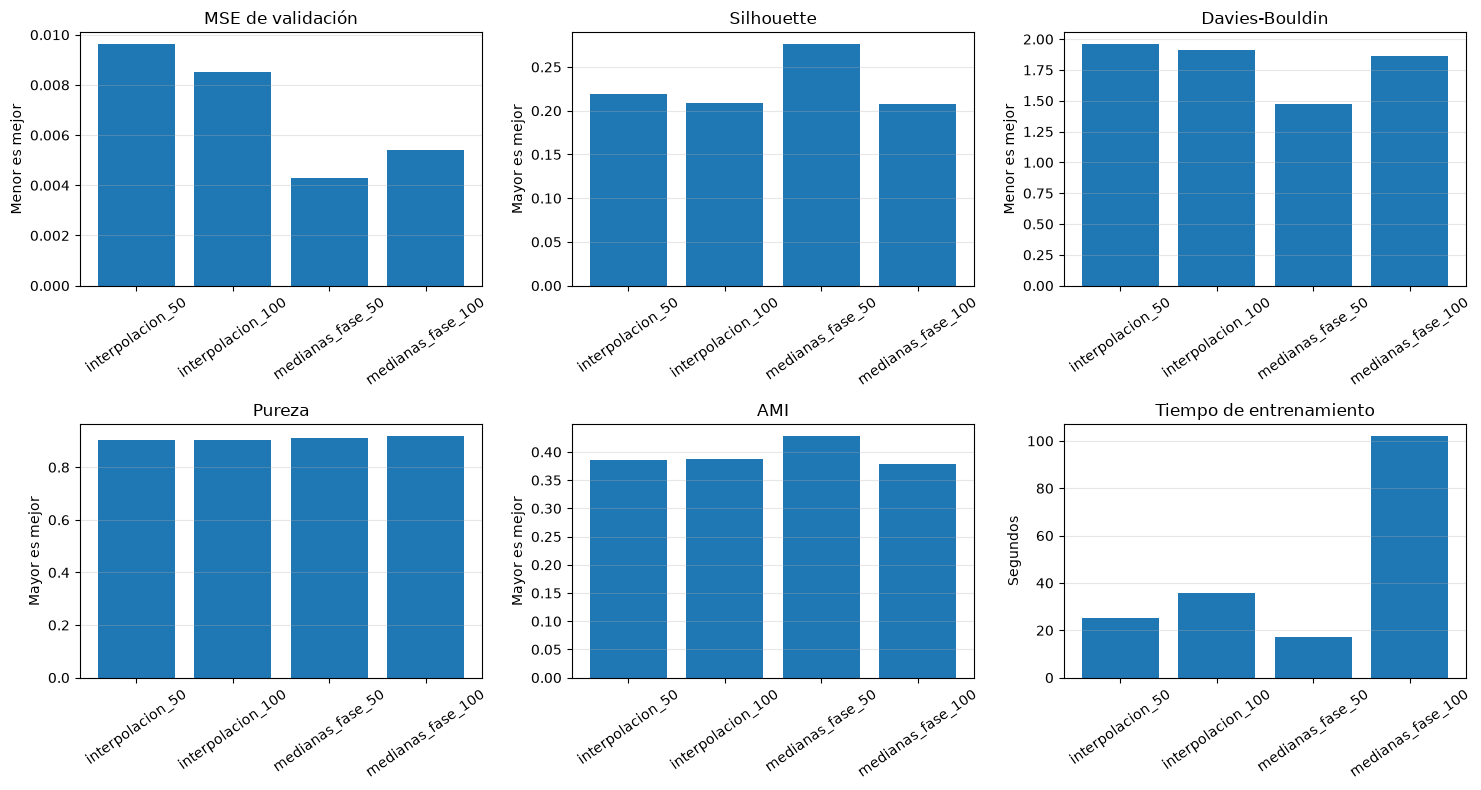

In [6]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8),
)

metricas_grafico = [
    (
        "mse_val",
        "MSE de validación",
        "Menor es mejor",
    ),
    (
        "silhouette_val",
        "Silhouette",
        "Mayor es mejor",
    ),
    (
        "davies_bouldin_val",
        "Davies-Bouldin",
        "Menor es mejor",
    ),
    (
        "purity_val",
        "Pureza",
        "Mayor es mejor",
    ),
    (
        "ami_val",
        "AMI",
        "Mayor es mejor",
    ),
    (
        "tiempo_entrenamiento_segundos",
        "Tiempo de entrenamiento",
        "Segundos",
    ),
]

for ax, (columna, titulo, criterio) in zip(
    axes.flat,
    metricas_grafico,
):
    ax.bar(
        df_resultados_representacion["dataset"],
        df_resultados_representacion[columna],
    )

    ax.set_title(titulo)
    ax.set_ylabel(criterio)
    ax.tick_params(
        axis="x",
        rotation=35,
    )
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
CARPETA_SELECCION_AA = (
    PROJECT_ROOT
    / "resultados"
    / "seleccion_parametros_aa"
)

CARPETA_SELECCION_AA.mkdir(
    parents=True,
    exist_ok=True,
)

ruta_resultados_csv = (
    CARPETA_SELECCION_AA
    / "seleccion_representacion_aa.csv"
)

ruta_resultados_parquet = (
    CARPETA_SELECCION_AA
    / "seleccion_representacion_aa.parquet"
)

df_resultados_representacion.to_csv(
    ruta_resultados_csv,
    index=False,
)

df_resultados_representacion.to_parquet(
    ruta_resultados_parquet,
    index=False,
)

print("Representación seleccionada: medianas_fase_50")
print(f"Resultados CSV: {ruta_resultados_csv}")
print(f"Resultados Parquet: {ruta_resultados_parquet}")

Representación seleccionada: medianas_fase_50
Resultados CSV: c:\Users\adanm\Code\tesis\resultados\seleccion_parametros_aa\seleccion_representacion_aa.csv
Resultados Parquet: c:\Users\adanm\Code\tesis\resultados\seleccion_parametros_aa\seleccion_representacion_aa.parquet
